In [1]:
from sklift.datasets import fetch_lenta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

from catboost import CatBoostClassifier, Pool
import shap

from causalml.metrics import plot_gain, auuc_score
import optuna

from sklearn.metrics import auc
from IPython.display import clear_output

from copy import deepcopy
from sklearn.utils.validation import check_consistent_length
# from tqdm import tqdm
import networkx as nx
from tqdm.auto import tqdm
# from utils import relative_uplift_auc_score, principled_uplift_curve, max_principled_uplift_curve, principled_uplift_auc_score, plot_principled_uplift_curve, sep_qini_auc_score

import warnings
warnings.filterwarnings('ignore')

from sklearn.utils.extmath import stable_cumsum
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import auc
from scipy import stats
from itertools import combinations

from causallearn.search.ConstraintBased.PC import pc

from sklift.metrics import uplift_by_percentile

/Users/kolpakovaksenia/diploma/.dvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/kolpakovaksenia/diploma/.dvenv/bin/python


In [3]:
SEED = 42

In [4]:
BASE_MODEL = CatBoostClassifier(
    loss_function='Logloss',
    verbose=False,
    random_state=SEED
  )

In [5]:
dataset = fetch_lenta()
data, target, treatment = dataset.data, dataset.target, dataset.treatment

In [6]:
# Преобразование признака gender
data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})
data['gender'] = data['gender'].fillna(-1)

In [7]:
# Заполнение пропусков
data = data.fillna(-100)

In [8]:
# Удаление явных дубликатов
data = data.drop_duplicates()

In [9]:
# Разбиение на train, valid, test выборки

data['treatment'] = treatment
data['treatment'] = (data['treatment'] == 'test').astype(int)
data['target'] = target

train_val_idx, test_idx = train_test_split(data.index, test_size=0.2, random_state=SEED, stratify=data[['treatment', 'target']])

train_idx, val_idx = train_test_split(train_val_idx, test_size=0.25, random_state=SEED, stratify=data.loc[train_val_idx, ['treatment', 'target']])

X_train = data.drop(columns=['treatment', 'target']).loc[train_idx]
X_val = data.drop(columns=['treatment', 'target']).loc[val_idx]
X_test = data.drop(columns=['treatment', 'target']).loc[test_idx]

treatment_train = data['treatment'][train_idx]
treatment_val = data['treatment'][val_idx]
treatment_test = data['treatment'][test_idx]

y_train = target[train_idx]
y_val = target[val_idx]
y_test = target[test_idx]

In [10]:
X_val.shape

(137397, 193)

In [11]:
def get_uplift(model_t, model_c, X, treatment, y, selected_features):
    X_selected = X[selected_features]
    
    pred_c = model_c.predict_proba(X_selected)[:, 1]
    pred_t = model_t.predict_proba(X_selected)[:, 1]
    
    uplift_pred = pred_t - pred_c
    
    pred_data = pd.DataFrame({'uplift': uplift_pred,
                            'y': y,
                            'treatment': treatment})
    auuc = auuc_score(pred_data, outcome_col='y', treatment_col='treatment')
    puc = principled_uplift_auc_score(y, uplift_pred, treatment)
  
    print('AUUC:', auuc.squeeze())
    print('PUC:', puc)
    
    return uplift_pred, auuc, puc

In [12]:
def train_tlearner(base_model, X_train, treatment_train, y_train,
                   X_val, treatment_val, y_val,
                   selected_features, n_trials=50, metrics='puc'):

    X_train = pd.concat([X_train, treatment_train], axis=1)
    y_train = pd.concat([y_train, treatment_train], axis=1)

    base_params = {
        'loss_function': 'Logloss',
        'verbose': False,
        'random_state': SEED
    }

    def objective(trial):

        params_c = {
            'depth': trial.suggest_int('depth_c', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_c', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_c', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_c', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_c', 0, 10),
            'random_strength': trial.suggest_float('random_strength_c', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_c', 1, 100),
        }

        params_t = {
            'depth': trial.suggest_int('depth_t', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate_t', 0.01, 0.3, log=True),
            'iterations': trial.suggest_int('iterations_t', 300, 1500),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg_t', 1, 20),
            'bagging_temperature': trial.suggest_float('bagging_temperature_t', 0, 10),
            'random_strength': trial.suggest_float('random_strength_t', 0, 10),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf_t', 1, 100),
        }

        X_c = X_train[treatment_train == 0][selected_features]
        y_c = y_train[treatment_train == 0]['response_att']

        X_t = X_train[treatment_train == 1][selected_features]
        y_t = y_train[treatment_train == 1]['response_att']

        model_c = base_model.__class__(**{**params_c, **base_params})
        model_c.fit(X_c, y_c)

        model_t = base_model.__class__(**{**params_t, **base_params})
        model_t.fit(X_t, y_t)

        _, auuc_val, puc_val = get_uplift(
            model_t,
            model_c,
            X_val,
            treatment_val,
            y_val,
            selected_features
        )

        if metrics == 'auuc':
            return auuc_val.item()
        
        elif metrics == 'puc':
            return puc_val


    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, n_jobs=-1)

    best_params = study.best_params

    params_c = {
        'depth': best_params['depth_c'],
        'learning_rate': best_params['learning_rate_c'],
        'iterations': best_params['iterations_c'],
        'l2_leaf_reg': best_params['l2_leaf_reg_c'],
        'bagging_temperature': best_params['bagging_temperature_c'],
        'random_strength': best_params['random_strength_c'],
        'min_data_in_leaf': best_params['min_data_in_leaf_c'],
    }

    params_t = {
        'depth': best_params['depth_t'],
        'learning_rate': best_params['learning_rate_t'],
        'iterations': best_params['iterations_t'],
        'l2_leaf_reg': best_params['l2_leaf_reg_t'],
        'bagging_temperature': best_params['bagging_temperature_t'],
        'random_strength': best_params['random_strength_t'],
        'min_data_in_leaf': best_params['min_data_in_leaf_t'],
    }

    X_c = X_train[treatment_train == 0][selected_features]
    y_c = y_train[treatment_train == 0]['response_att']

    X_t = X_train[treatment_train == 1][selected_features]
    y_t = y_train[treatment_train == 1]['response_att']

    model_c = base_model.__class__(**{**params_c, **base_params})
    model_c.fit(X_c, y_c)

    model_t = base_model.__class__(**{**params_t, **base_params})
    model_t.fit(X_t, y_t)

    uplift_pred_train, auuc_train, puc_train = get_uplift(
        model_t,
        model_c,
        X_train,
        treatment_train,
        y_train['response_att'],
        selected_features
    )

    return model_t, model_c, uplift_pred_train, auuc_train, puc_train, study

In [13]:
def check_is_binary(array):
    if not np.all(np.unique(array) == np.array([0, 1])):
        raise ValueError(
            f'Input array is not binary. Got values {np.unique(array)}.'
        )
        
def principled_uplift_curve(y_true, uplift, treatment):
    
    check_consistent_length(y_true, uplift, treatment)
    check_is_binary(treatment)
    check_is_binary(y_true)

    y_true = np.array(y_true)
    uplift = np.array(uplift)
    treatment = np.array(treatment)

    desc_score_indices = np.argsort(uplift, kind='mergesort')[::-1]
    y_true = y_true[desc_score_indices]
    treatment = treatment[desc_score_indices]

    n_y1_t1 = np.zeros_like(y_true)
    n_y0_t0 = np.zeros_like(y_true)
    n_y1_t0 = np.zeros_like(y_true)
    n_y0_t1 = np.zeros_like(y_true)

    n_y1_t1[np.where((y_true == 1) & (treatment == 1))] = 1
    n_y0_t0[np.where((y_true == 0) & (treatment == 0))] = 1
    n_y1_t0[np.where((y_true == 1) & (treatment == 0))] = 1
    n_y0_t1[np.where((y_true == 0) & (treatment == 1))] = 1
    
    cum_y1_t1 = stable_cumsum(n_y1_t1)
    cum_y0_t0 = stable_cumsum(n_y0_t0)
    cum_y1_t0 = stable_cumsum(n_y1_t0)
    cum_y0_t1 = stable_cumsum(n_y0_t1)

    curve_values = cum_y1_t1 + cum_y0_t0 - cum_y1_t0 - cum_y0_t1
    return curve_values

def max_principled_uplift_curve(y_true, treatment):

    check_consistent_length(y_true, treatment)
    check_is_binary(treatment)
    check_is_binary(y_true)

    y_true = np.array(y_true)
    treatment = np.array(treatment)

    perfect_uplift = np.zeros_like(y_true)
    perfect_uplift[treatment == y_true] = 1

    return principled_uplift_curve(y_true, perfect_uplift, treatment)

def principled_uplift_auc_score(y_true, uplift, treatment):
    
    check_consistent_length(y_true, uplift, treatment)
    check_is_binary(treatment)
    check_is_binary(y_true)

    y_true = np.array(y_true)
    uplift = np.array(uplift)
    treatment = np.array(treatment)

    x_actual = np.array(range(len(y_true)))
    y_actual = principled_uplift_curve(y_true, uplift, treatment)
    y_perfect = max_principled_uplift_curve(y_true, treatment)

    x_baseline = np.array([0, x_actual[-1]])
    y_baseline = np.array([0, y_perfect[-1]])

    auc_baseline = auc(x_baseline, y_baseline)
    auc_perfect = auc(x_actual, y_perfect) - auc_baseline
    auc_actual = auc(x_actual, y_actual) - auc_baseline

    if auc_perfect == 0:
        return 0.0
    return auc_actual / auc_perfect


In [14]:
def _compute_puc_for_feature(X_col, y, treatment, n_bins=5):
    
    X_col = np.array(X_col, dtype=float)
    
    col_range = X_col.max() - X_col.min()
    if col_range == 0:
        return 0.0
    X_norm = (X_col - X_col.min()) / col_range

    try:
        score = principled_uplift_auc_score(y, X_norm, treatment)
    except Exception:
        score = 0.0
    return score

In [15]:
def _compute_marginal_puc(X, y, treatment, selected_features, candidate):
    
    if len(selected_features) == 0:
        base_scores = np.zeros(len(y))
    else:
        base_scores = X[:, selected_features].mean(axis=1)
        base_range = base_scores.max() - base_scores.min()
        if base_range > 0:
            base_scores = (base_scores - base_scores.min()) / base_range

    cand_scores = X[:, candidate].copy()
    cand_range = cand_scores.max() - cand_scores.min()
    if cand_range > 0:
        cand_scores = (cand_scores - cand_scores.min()) / cand_range

    combined = (base_scores + cand_scores) / 2

    try:
        return principled_uplift_auc_score(y, combined, treatment)
    except Exception:
        return 0.0

### Метод 3 - puc_permutation_importance — Permutation Importance на основе PUC

In [30]:
def puc_permutation_importance(
    X,
    y,
    treatment,
    uplift_scores,
    n_repeats=20,
    random_state=42,
    feature_names=None
):

    X = np.array(X, dtype=float)
    y = np.array(y)
    treatment = np.array(treatment)
    uplift_scores = np.array(uplift_scores, dtype=float)
    n_features = X.shape[1]
    
    base_score = principled_uplift_auc_score(y, uplift_scores, treatment)
    
    rng = np.random.RandomState(random_state)
    importances = np.zeros((n_features, n_repeats))
    
    for feat_idx in range(n_features):
        for rep in range(n_repeats):
            X_permuted = X.copy()
            X_permuted[:, feat_idx] = rng.permutation(X[:, feat_idx])
            
            perm_score_col = X_permuted[:, feat_idx]
            col_range = perm_score_col.max() - perm_score_col.min()
            if col_range > 0:
                perm_score_col = (perm_score_col - perm_score_col.min()) / col_range
            
            blended = 0.5 * uplift_scores + 0.5 * perm_score_col
            blended_range = blended.max() - blended.min()
            if blended_range > 0:
                blended = (blended - blended.min()) / blended_range
            
            try:
                perm_puc = principled_uplift_auc_score(y, blended, treatment)
            except Exception:
                perm_puc = base_score
            
            importances[feat_idx, rep] = base_score - perm_puc
    
    importances_mean = importances.mean(axis=1)
    importances_std = importances.std(axis=1)
    
    summary_df = pd.DataFrame({
        'feature': feature_names,
        'importance_mean': importances_mean,
        'importance_std': importances_std,
    }).sort_values('importance_mean', ascending=False).reset_index(drop=True)
    
    return importances, importances_mean, importances_std, base_score, summary_df

In [31]:
model_trt = BASE_MODEL.copy()
model_ctrl = BASE_MODEL.copy()

model_trt.fit(X_train[treatment_train == 1], y_train[treatment_train == 1])
model_ctrl.fit(X_train[treatment_train == 0], y_train[treatment_train == 0])

CatBoostClassifier(loss_function='Logloss', random_state=42, verbose=False)

In [32]:
uplift_scores = model_trt.predict(X_val) - model_ctrl.predict(X_val)

importances, imp_mean, imp_std, base_score, summary_df = puc_permutation_importance(
    X=X_val,
    y=y_val,
    treatment=treatment_val,
    uplift_scores=uplift_scores,
    n_repeats=10,
    random_state=42,
    feature_names=X_train.columns.tolist()
)

In [33]:
selected_features_puc_pi = summary_df[summary_df.importance_mean > 0]['feature']

### Построение каузального графа

In [47]:
df_val = pd.concat([
    X_val.reset_index(drop=True),
    pd.Series(treatment_val.values, name='treatment'),
    pd.Series(y_val.values, name='target')
], axis=1)


cat_cols = df_val.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['treatment', 'target']]

for c in tqdm(cat_cols, desc="Encoding val categoricals", leave=False):
    df_val[c] = LabelEncoder().fit_transform(df_val[c].astype(str))

df_val = df_val.fillna(df_val.median(numeric_only=True))

feature_cols = [c for c in df_val.columns if c not in ['treatment', 'target']]
feature_cols = list(feature_cols)

selected_features = selected_features_puc_pi[:50].values.tolist()
selected_features = list(selected_features)

In [50]:
sampled_parts = []
for (t, y), group in df_val.groupby(['treatment', 'target']):
    n_sample = min(3000, len(group))
    sampled_parts.append(group.sample(n=n_sample, random_state=SEED))

df_val_sample = pd.concat(sampled_parts, ignore_index=True)

In [51]:
df_val_sample.shape

(12000, 195)

In [52]:
cols_for_graph = ['treatment'] + list(selected_features) + ['target']

df_graph = df_val_sample[cols_for_graph].copy()

scaler = StandardScaler()
df_graph_scaled = pd.DataFrame(
    scaler.fit_transform(df_graph),
    columns=df_graph.columns
)

print(f'Матрица для PC: {df_graph_scaled.shape}')

Матрица для PC: (12000, 52)


In [53]:
def learn_graph_pc_uplift(df, treatment_col='treatment', outcome_col='target', 
                          alpha=0.05):
    data = df.values
    cols = list(df.columns)
    n_cols = len(cols)
    
    node_name_to_col = {}
    for i, col in enumerate(cols):
        node_name_to_col[f"X{i}"] = col
        node_name_to_col[f"X{i+1}"] = col
    
    def _resolve_node(node):
        name = node.get_name()
        
        if name in node_name_to_col:
            return node_name_to_col[name]
        if name in cols:
            return name
        
        if isinstance(name, str) and name.startswith('X'):
            try:
                idx = int(name[1:])
                if 0 <= idx < n_cols:
                    return cols[idx]
                if 1 <= idx <= n_cols:
                    return cols[idx - 1]
            except ValueError:
                pass
        
        raise ValueError(f'Не удалось сопоставить узел "{name}" с колонками.'
                         f'Всего колонок: {n_cols}, ожидались имена вида X1..X{n_cols}')
    
    print(f'Запуск PC-algorithm: {n_cols} узлов, alpha={alpha}')
    cg = pc(data, alpha=alpha, indep_test='fisherz', stable=False)
    
    G = nx.DiGraph()
    for c in cols:
        G.add_node(c)
    
    edges = cg.G.get_graph_edges()
    for edge in tqdm(edges, desc='Parsing edges', total=len(edges), leave=False):
        n1 = _resolve_node(edge.get_node1())
        n2 = _resolve_node(edge.get_node2())
        ep1 = edge.get_endpoint1().name
        ep2 = edge.get_endpoint2().name
        
        if ep1 == 'TAIL' and ep2 == 'ARROW':
            G.add_edge(n1, n2)
        elif ep1 == 'ARROW' and ep2 == 'TAIL':
            G.add_edge(n2, n1)
        elif ep1 == 'TAIL' and ep2 == 'TAIL':
            G.add_edge(n1, n2)
            G.add_edge(n2, n1)

    for pred in list(G.predecessors(treatment_col)):
        G.remove_edge(pred, treatment_col)
    
    if not G.has_edge(treatment_col, outcome_col):
        G.add_edge(treatment_col, outcome_col)
    
    for succ in list(G.successors(outcome_col)):
        G.remove_edge(outcome_col, succ)
    
    return G, cg

In [54]:
def causal_feature_select(G, treatment='treatment', outcome='target'):
    features = [n for n in G.nodes() if n not in [treatment, outcome]]
    
    parents_y = set(G.predecessors(outcome))
    children_y = set(G.successors(outcome))
    
    spouses_y = set()
    for ch in children_y:
        for pred in G.predecessors(ch):
            if pred != outcome and pred != treatment:
                spouses_y.add(pred)
    
    mb_outcome = parents_y.union(children_y).union(spouses_y)
    mb_outcome.discard(treatment)
    
    ancestors_t = set(nx.ancestors(G, treatment))
    ancestors_y = set(nx.ancestors(G, outcome))
    
    effect_zone = ancestors_t.intersection(ancestors_y)
    
    for node in features:
        if node not in effect_zone:
            has_path_to_t = nx.has_path(G, node, treatment) if node != treatment else False
            has_path_to_y = nx.has_path(G, node, outcome) if node != outcome else False
            if has_path_to_t and has_path_to_y:
                effect_zone.add(node)
    
    prognostic = ancestors_y - {treatment} - ancestors_t
    
    effect_zone_clean = effect_zone - prognostic - mb_outcome
    prognostic_clean = prognostic - mb_outcome
    return {
        'mb_target': sorted([f for f in mb_outcome if f in features]),
        'effect_modifiers': sorted([f for f in effect_zone_clean if f in features]),
        'prognostic': sorted([f for f in prognostic_clean if f in features]),
        'combined_uplift': sorted(list(
            set(mb_outcome).union(effect_zone).union(prognostic)
        ))
    }


In [55]:
def plot_causal_graph(G, causal_sets, plot_causal_title='Causal Graph (learned on validation)'):
    pos = nx.spring_layout(G, k=2.0, iterations=50, seed=42)
    plt.figure(figsize=(16, 12))
    
    node_colors = []
    for n in G.nodes():
        if n == 'treatment':
            node_colors.append('red')
        elif n == 'target':
            node_colors.append('green')
        elif n in causal_sets.get('effect_modifiers', []):
            node_colors.append('yellow')
        elif n in causal_sets.get('mb_target', []):
            node_colors.append('blue')
        elif n in causal_sets.get('prognostic', []):
            node_colors.append('orange')
        else:
            node_colors.append('grey')
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                           node_size=700, alpha=0.9, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')
    nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=12,
                           edge_color='black', width=1.0, alpha=0.7,
                           connectionstyle='arc3,rad=0.1')
    
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Treatment'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Target'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=10, label='Effect Modifier'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='MB(Target)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='Prognostic'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=10, label='Other'),
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.title(plot_causal_title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [56]:
G, cg_raw = learn_graph_pc_uplift(df_graph, alpha=0.05)

Запуск PC-algorithm: 52 узлов, alpha=0.05


Depth=15, working on node 51: 100%|███████████| 52/52 [00:00<00:00, 4657.85it/s]


In [57]:
print(f"Число узлов: {G.number_of_nodes()}")
print(f"Число ребер: {G.number_of_edges()}")

Число узлов: 52
Число ребер: 170


In [58]:
causal_sets = causal_feature_select(G)

In [62]:
causal_sets

{'mb_target': ['cheque_count_6m_g33',
  'k_var_count_per_cheque_1m_g27',
  'k_var_count_per_cheque_3m_g44',
  'k_var_disc_share_6m_g49',
  'sale_count_12m_g32'],
 'effect_modifiers': [],
 'prognostic': ['cheque_count_12m_g20',
  'cheque_count_12m_g25',
  'cheque_count_12m_g33',
  'cheque_count_12m_g39',
  'cheque_count_12m_g42',
  'cheque_count_12m_g48',
  'k_var_cheque_3m',
  'k_var_cheque_category_width_15d',
  'k_var_count_per_cheque_1m_g34',
  'k_var_count_per_cheque_6m_g44',
  'k_var_disc_share_3m_g34',
  'k_var_disc_share_3m_g44',
  'k_var_disc_share_3m_g54',
  'k_var_disc_share_6m_g44',
  'k_var_disc_share_6m_g46',
  'k_var_disc_share_6m_g54',
  'k_var_sku_price_12m_g32',
  'k_var_sku_price_3m_g49',
  'k_var_sku_price_3m_g54',
  'k_var_sku_price_6m_g24',
  'k_var_sku_price_6m_g26',
  'k_var_sku_price_6m_g32',
  'k_var_sku_price_6m_g41',
  'k_var_sku_price_6m_g49',
  'months_from_register',
  'promo_share_15d',
  'response_viber',
  'sale_count_12m_g33',
  'sale_count_12m_g54',
 

In [59]:
len(causal_sets['combined_uplift'])

48

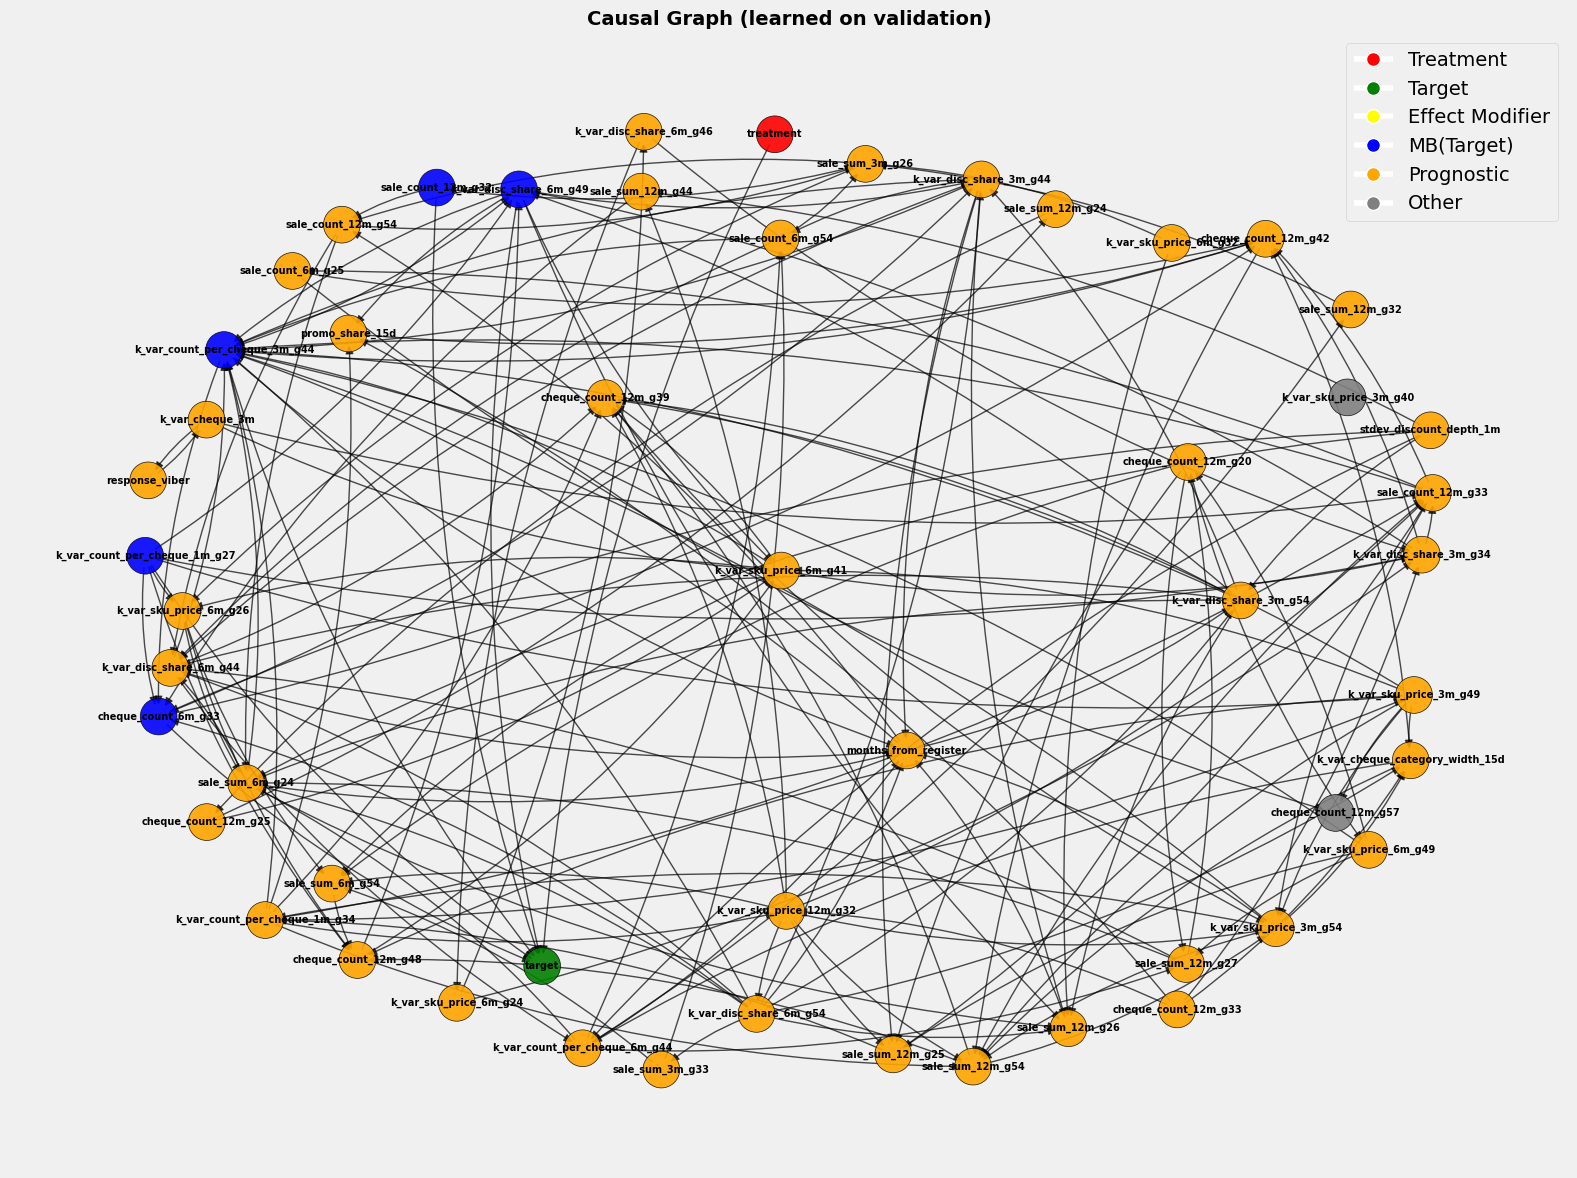

In [61]:
plot_causal_graph(G,causal_sets)

In [63]:
model_t_v7, model_c_v7, uplift_pred_train_v7, auuc_train_v7, puc_train_v7, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, causal_sets['combined_uplift'])

[I 2026-05-03 08:17:48,721] A new study created in memory with name: no-name-99411f3a-e4a5-4dde-b3b6-2c35ad660e22
[I 2026-05-03 08:18:48,696] Trial 11 finished with value: 0.05858671924258229 and parameters: {'depth_c': 5, 'learning_rate_c': 0.01129826172012697, 'iterations_c': 647, 'l2_leaf_reg_c': 18.894982910551825, 'bagging_temperature_c': 4.693480309399062, 'random_strength_c': 8.75286880680336, 'min_data_in_leaf_c': 21, 'depth_t': 4, 'learning_rate_t': 0.03110990227081936, 'iterations_t': 509, 'l2_leaf_reg_t': 10.681818959068574, 'bagging_temperature_t': 4.328463968652093, 'random_strength_t': 0.9047446605408072, 'min_data_in_leaf_t': 59}. Best is trial 11 with value: 0.05858671924258229.


AUUC: 0.7435305727348679
PUC: 0.05858671924258229


[I 2026-05-03 08:19:06,435] Trial 1 finished with value: 0.051175368277767794 and parameters: {'depth_c': 6, 'learning_rate_c': 0.011090099743941083, 'iterations_c': 449, 'l2_leaf_reg_c': 12.250075039849062, 'bagging_temperature_c': 3.823750138765676, 'random_strength_c': 9.65960555595921, 'min_data_in_leaf_c': 24, 'depth_t': 9, 'learning_rate_t': 0.01039478640926139, 'iterations_t': 409, 'l2_leaf_reg_t': 13.813037334454684, 'bagging_temperature_t': 1.704915657346553, 'random_strength_t': 3.2318785133592653, 'min_data_in_leaf_t': 42}. Best is trial 11 with value: 0.05858671924258229.


AUUC: 0.660713387287599
PUC: 0.051175368277767794


[I 2026-05-03 08:19:07,186] Trial 6 finished with value: -0.004408562531097511 and parameters: {'depth_c': 5, 'learning_rate_c': 0.07550819175557372, 'iterations_c': 1050, 'l2_leaf_reg_c': 11.515283199311307, 'bagging_temperature_c': 7.466321473493459, 'random_strength_c': 6.203656463805057, 'min_data_in_leaf_c': 93, 'depth_t': 4, 'learning_rate_t': 0.0222863885618785, 'iterations_t': 572, 'l2_leaf_reg_t': 4.688972808532106, 'bagging_temperature_t': 2.895292370386886, 'random_strength_t': 2.1899967958204805, 'min_data_in_leaf_t': 52}. Best is trial 11 with value: 0.05858671924258229.


...

AUUC: 0.6664270115377879
PUC: 0.06423511853510074


[I 2026-05-03 08:28:04,253] Trial 49 finished with value: 0.05809772775772162 and parameters: {'depth_c': 5, 'learning_rate_c': 0.01855071068238942, 'iterations_c': 304, 'l2_leaf_reg_c': 16.37679563238833, 'bagging_temperature_c': 0.12243004011514191, 'random_strength_c': 8.623852434388631, 'min_data_in_leaf_c': 14, 'depth_t': 6, 'learning_rate_t': 0.05820574198482273, 'iterations_t': 447, 'l2_leaf_reg_t': 11.989323624339626, 'bagging_temperature_t': 1.3301316084492658, 'random_strength_t': 1.088138836070703, 'min_data_in_leaf_t': 79}. Best is trial 31 with value: 0.06799856836847556.


AUUC: 0.666288203616036
PUC: 0.05809772775772162


[I 2026-05-03 08:28:05,184] Trial 37 finished with value: 0.04696219992935872 and parameters: {'depth_c': 5, 'learning_rate_c': 0.014883799587773935, 'iterations_c': 608, 'l2_leaf_reg_c': 9.650421729931633, 'bagging_temperature_c': 0.759679521506299, 'random_strength_c': 8.126077860923099, 'min_data_in_leaf_c': 11, 'depth_t': 10, 'learning_rate_t': 0.030535973711755277, 'iterations_t': 498, 'l2_leaf_reg_t': 12.633955567207503, 'bagging_temperature_t': 0.025227590522172605, 'random_strength_t': 1.2257947296151381, 'min_data_in_leaf_t': 72}. Best is trial 31 with value: 0.06799856836847556.


AUUC: 0.6288517692656709
PUC: 0.04696219992935872
AUUC: 2.4944943436331304
PUC: 0.17208097368366615


In [64]:
uplift_pred_test_v7, auuc_test_v7, puc_test_v7 = get_uplift(model_t_v7, 
                                                            model_c_v7, 
                                                            X_test, 
                                                            treatment_test, 
                                                            y_test, 
                                                            causal_sets['combined_uplift'])

AUUC: 0.6466736864834549
PUC: 0.07199116928610627


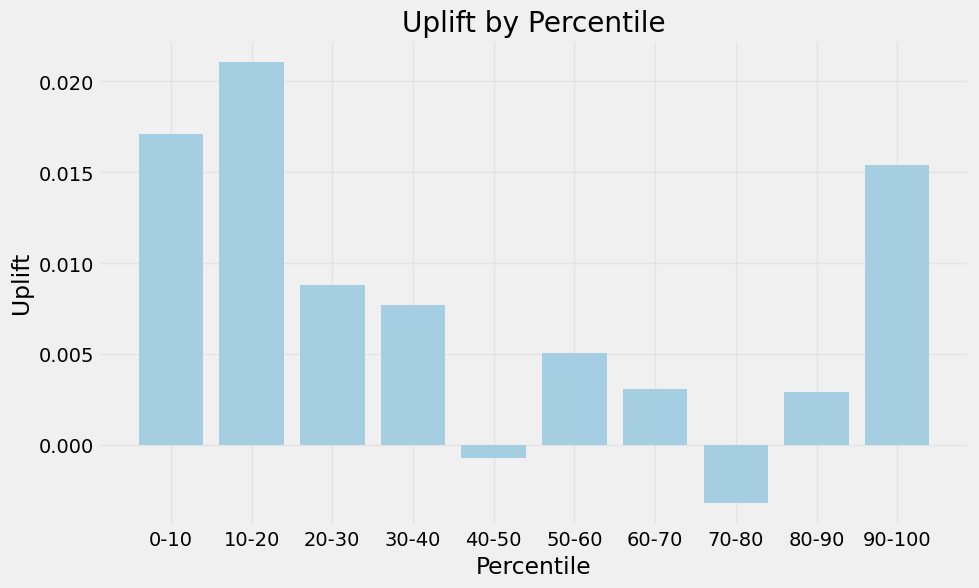

In [65]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v7, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()

вторая попытка

In [70]:
cols_for_graph_v2 = ['treatment'] + selected_features_puc_pi[:80].values.tolist() + ['target']

df_graph_v2 = df_val_sample[cols_for_graph_v2].copy()

scaler = StandardScaler()
df_graph_scaled_v2 = pd.DataFrame(
    scaler.fit_transform(df_graph_v2),
    columns=df_graph_v2.columns
)

print(f'Матрица для PC: {df_graph_scaled_v2.shape}')

Матрица для PC: (12000, 82)


In [71]:
G_v2, cg_raw_v2 = learn_graph_pc_uplift(df_graph_scaled_v2, alpha=0.05)

Запуск PC-algorithm: 82 узлов, alpha=0.05



Depth=15, working on node 81: 100%|███████████| 82/82 [00:00<00:00, 2235.67it/s]

Parsing edges:   0%|                                    | 0/243 [00:00<?, ?it/s]
                                                                                

In [72]:
print(f"Число узлов: {G_v2.number_of_nodes()}")
print(f"Число ребер: {G_v2.number_of_edges()}")

Число узлов: 82
Число ребер: 251


In [73]:
causal_sets_v2 = causal_feature_select(G_v2)

In [75]:
len(causal_sets_v2['combined_uplift'])

69

Depth=6, working on node 2:   6%|▊            | 3/52 [09:02<2:27:46, 180.95s/it]


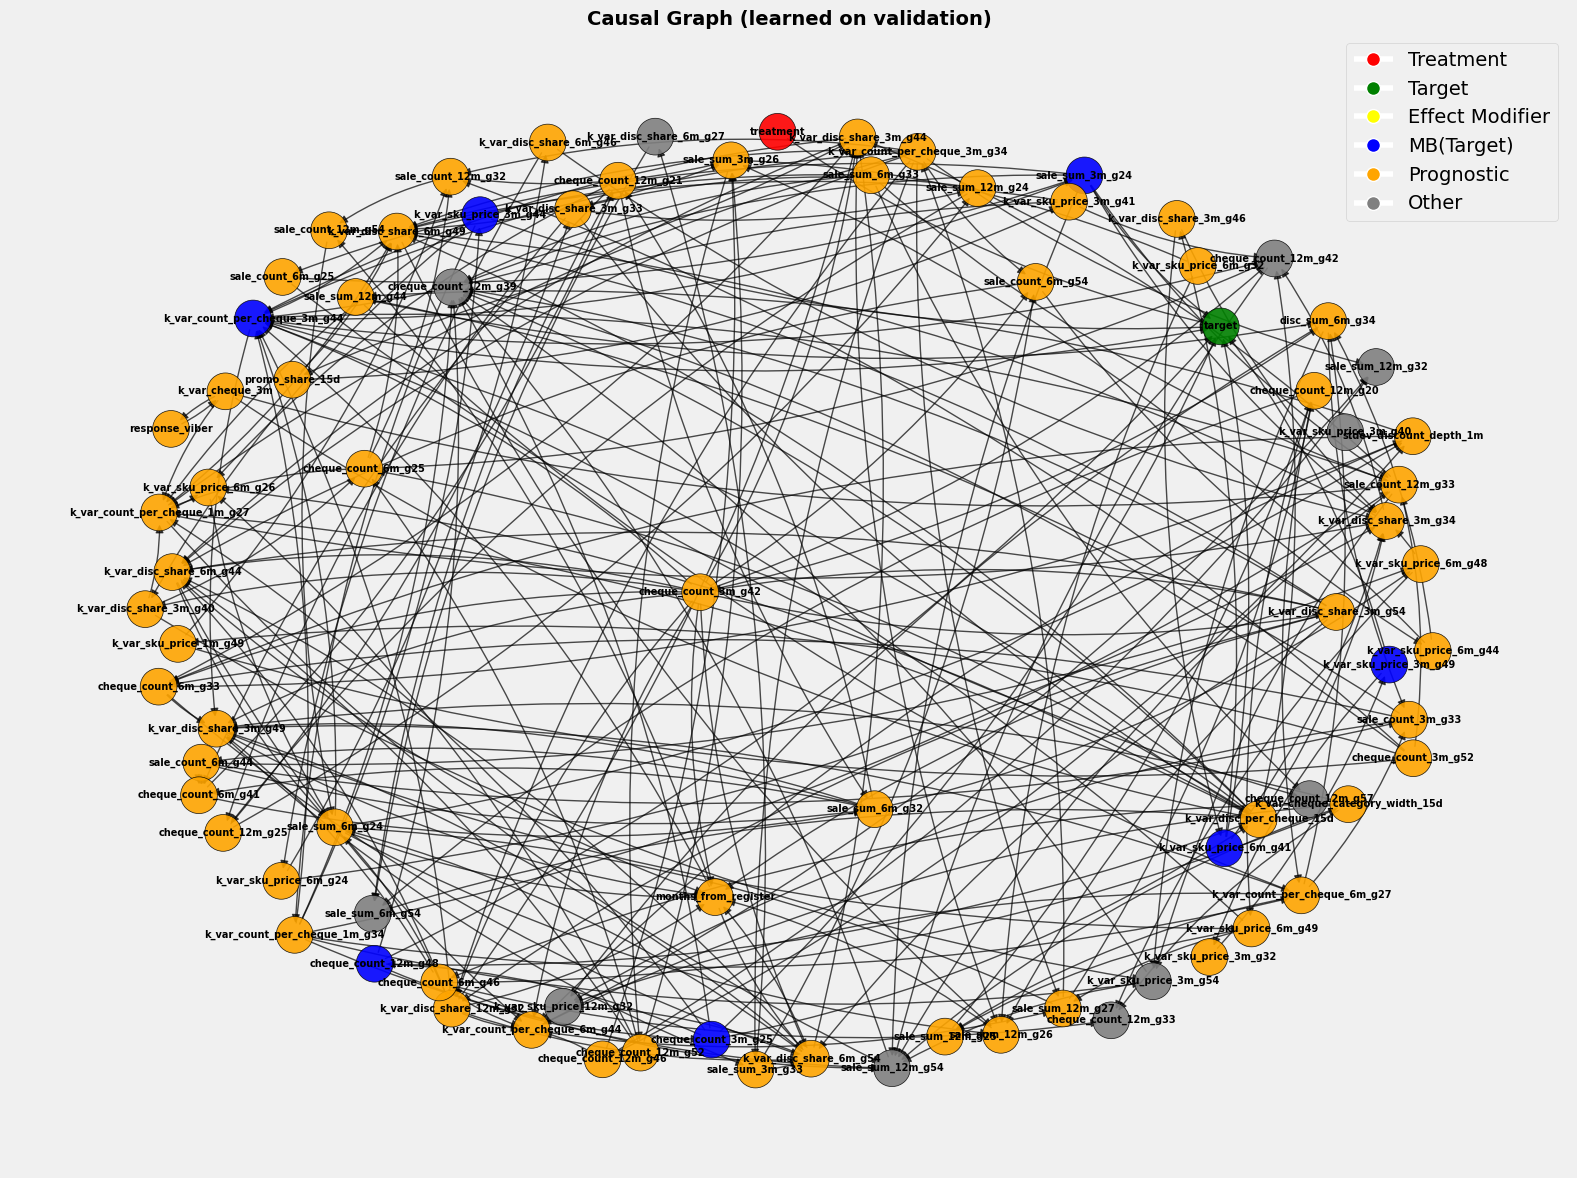

In [76]:
plot_causal_graph(G_v2, causal_sets_v2)

In [77]:
model_t_v8, model_c_v8, uplift_pred_train_v8, auuc_train_v8, puc_train_v8, study = train_tlearner(
    BASE_MODEL, X_train, treatment_train, y_train, 
    X_val, treatment_val, y_val, causal_sets_v2['combined_uplift'])

[I 2026-05-03 08:39:57,945] A new study created in memory with name: no-name-43b0d5e2-4a55-4c92-883d-35f940b56a48
[I 2026-05-03 08:41:23,447] Trial 6 finished with value: 0.012180039971939427 and parameters: {'depth_c': 4, 'learning_rate_c': 0.20441075005243625, 'iterations_c': 1340, 'l2_leaf_reg_c': 6.946496513192832, 'bagging_temperature_c': 7.121745075463096, 'random_strength_c': 0.42968620965273097, 'min_data_in_leaf_c': 81, 'depth_t': 5, 'learning_rate_t': 0.057176277848517136, 'iterations_t': 373, 'l2_leaf_reg_t': 16.401306217198428, 'bagging_temperature_t': 7.372320528176644, 'random_strength_t': 7.222910215077574, 'min_data_in_leaf_t': 26}. Best is trial 6 with value: 0.012180039971939427.


AUUC: 0.5367098352548526
PUC: 0.012180039971939427


[I 2026-05-03 08:41:42,666] Trial 12 finished with value: 0.005752902393772311 and parameters: {'depth_c': 6, 'learning_rate_c': 0.11955660841052002, 'iterations_c': 948, 'l2_leaf_reg_c': 9.787069259261072, 'bagging_temperature_c': 9.33258282083365, 'random_strength_c': 8.622059010082186, 'min_data_in_leaf_c': 31, 'depth_t': 6, 'learning_rate_t': 0.02783320879872521, 'iterations_t': 512, 'l2_leaf_reg_t': 4.619904871215214, 'bagging_temperature_t': 3.143286382173965, 'random_strength_t': 6.249368602488744, 'min_data_in_leaf_t': 27}. Best is trial 6 with value: 0.012180039971939427.


AUUC: 0.47975077481337564
PUC: 0.005752902393772311


[I 2026-05-03 08:41:49,743] Trial 7 finished with value: 0.0340802150261596 and parameters: {'depth_c': 9, 'learning_rate_c': 0.22799139042061564, 'iterations_c': 561, 'l2_leaf_reg_c': 10.442855000510388, 'bagging_temperature_c': 0.6300206627352756, 'random_strength_c': 6.052900437477017, 'min_data_in_leaf_c': 96, 'depth_t': 4, 'learning_rate_t': 0.04902989900194822, 'iterations_t': 547, 'l2_leaf_reg_t': 9.719425029555829, 'bagging_temperature_t': 4.000691469874801, 'random_strength_t': 8.655272821378029, 'min_data_in_leaf_t': 19}. Best is trial 7 with value: 0.0340802150261596.


...

AUUC: 0.5975955018676209
PUC: 0.04372823829351846


[I 2026-05-03 08:54:54,118] Trial 49 finished with value: 0.041309497589965376 and parameters: {'depth_c': 8, 'learning_rate_c': 0.01821620456057494, 'iterations_c': 461, 'l2_leaf_reg_c': 19.022416508261095, 'bagging_temperature_c': 4.354034221837578, 'random_strength_c': 4.533602007408097, 'min_data_in_leaf_c': 61, 'depth_t': 7, 'learning_rate_t': 0.09567325798957625, 'iterations_t': 476, 'l2_leaf_reg_t': 3.412881741451392, 'bagging_temperature_t': 1.133856605701311, 'random_strength_t': 9.165139592731776, 'min_data_in_leaf_t': 90}. Best is trial 24 with value: 0.06442311690272352.


AUUC: 0.581388901278139
PUC: 0.041309497589965376


[I 2026-05-03 08:54:58,292] Trial 42 finished with value: 0.023607874786819347 and parameters: {'depth_c': 8, 'learning_rate_c': 0.01725387445737108, 'iterations_c': 453, 'l2_leaf_reg_c': 3.6001709145137912, 'bagging_temperature_c': 4.100589793631626, 'random_strength_c': 2.404513662437749, 'min_data_in_leaf_c': 58, 'depth_t': 10, 'learning_rate_t': 0.08376001005193684, 'iterations_t': 585, 'l2_leaf_reg_t': 6.486912763636633, 'bagging_temperature_t': 0.9483549797359685, 'random_strength_t': 8.13667482870446, 'min_data_in_leaf_t': 100}. Best is trial 24 with value: 0.06442311690272352.


AUUC: 0.5699979563681621
PUC: 0.023607874786819347
AUUC: 2.8817135786625587
PUC: 0.12654373442551742


In [78]:
uplift_pred_test_v8, auuc_test_v8, puc_test_v8 = get_uplift(model_t_v8, 
                                                            model_c_v8, 
                                                            X_test, 
                                                            treatment_test, 
                                                            y_test, 
                                                            causal_sets_v2['combined_uplift'])

AUUC: 0.5292144655054905
PUC: 0.06321194534509322


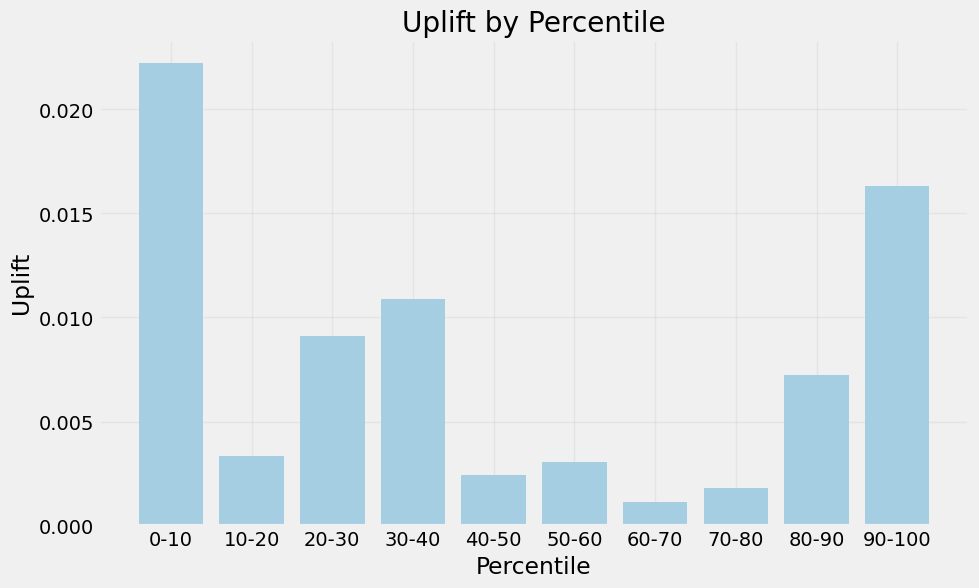

In [79]:
result = uplift_by_percentile(
    y_test, uplift_pred_test_v8, treatment_test, 
    strategy='overall', bins=10
)

plt.figure(figsize=(10, 6))
plt.bar(range(len(result)), result['uplift'])
plt.xlabel('Percentile')
plt.ylabel('Uplift')
plt.title('Uplift by Percentile')
plt.xticks(range(len(result)), result.index)
plt.grid(True, alpha=0.3)
plt.show()